# FMATCH 4/10 — The tile manager

**PR topic**: `libera_utils.footprint_matching.tiling` — the central data-access
layer between footprint bounding boxes (PR 1) and the ancillary readers (PRs 2–3).

Responsibilities demonstrated below:

1. **Resolve**: map a footprint's lat/lon `BoundingBox` to the set of 2°×2°
   `TileKey`s it touches (with dateline-wrapping boxes split into two sub-requests).
2. **Cache**: keep loaded `GridTile`s in a byte-budgeted [LRU cache](https://en.wikipedia.org/wiki/Cache_replacement_policies#LRU) — consecutive
   footprints overlap heavily, so most requests are cache hits.
3. **Merge**: stitch multiple cached tiles into one contiguous grid per request
   (with a small merge-result cache on top, since consecutive footprints often
   resolve to the *same* tile set).
4. **Prefetch**: optionally warm the cache for upcoming footprints from a background
   thread, overlapping reader I/O with the main thread's aggregation compute (all
   raw reads stay serialized behind one global lock — the native HDF5 stack is [not thread-safe](https://docs.h5py.org/en/stable/faq.html)).

In [1]:
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from libera_utils.footprint_matching import geometry
from libera_utils.footprint_matching.readers.era5 import ERA5Reader
from libera_utils.footprint_matching.tiling import TileManager
from libera_utils.footprint_matching.types import BoundingBox, OperationalMode
from tests.test_data.footprint_matching.fixtures import make_era5_netcdf_fixture

## Setup: a synthetic global ERA5 file and a TileManager

The manager is constructed with *instantiated readers for the active mode only* —
here just ERA5, on a coarse synthetic global file.

In [3]:
workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb04_"))
era5_path = make_era5_netcdf_fixture(
    workdir, lat_min=-90.0, lat_max=90.0, lon_min=-180.0, lon_max=180.0, n_lat=181, n_lon=361
)
manager = TileManager(
    readers={"era5": ERA5Reader(era5_path)},
    active_mode=OperationalMode.CAM,
    prefetch_lookahead=0,  # start with the synchronous path; prefetch demo at the end
)
print(f"sources={manager.sources}  mode={manager.active_mode.name}")

sources=['era5']  mode=CAM


## 1. Resolving a footprint bounding box to tile keys

A realistic footprint box from the PR-1 geometry (oblique view, so it spans several
degrees) resolves to the 2° tiles it overlaps:

In [4]:
bbox = geometry.compute_footprint_bounding_box(
    boresight_lat_deg=41.0,
    boresight_lon_deg=-104.0,
    subsatellite_lat_deg=45.5,
    subsatellite_lon_deg=-103.0,
    viewing_zenith_deg=55.0,
)
keys = manager.resolve_tile_keys("era5", bbox)
print(f"bbox lat [{bbox.lat_min:.2f}, {bbox.lat_max:.2f}] lon [{bbox.lon_min:.2f}, {bbox.lon_max:.2f}]")
print(f"resolves to {len(keys)} tiles: {[(k.lat_idx, k.lon_idx) for k in keys]}")

bbox lat [40.74, 41.24] lon [-104.19, -103.82]
resolves to 2 tiles: [(65, 37), (65, 38)]


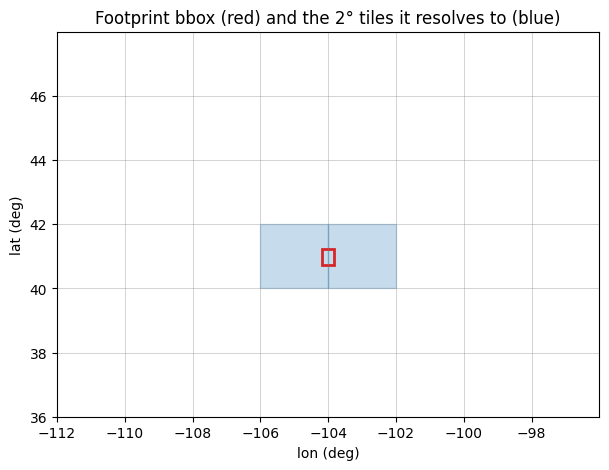

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for k in keys:
    lat0, lon0 = k.lat_idx * 2 - 90, k.lon_idx * 2 - 180
    ax.add_patch(plt.Rectangle((lon0, lat0), 2, 2, facecolor="tab:blue", alpha=0.25, edgecolor="tab:blue"))
ax.add_patch(
    plt.Rectangle(
        (bbox.lon_min, bbox.lat_min),
        bbox.lon_max - bbox.lon_min,
        bbox.lat_max - bbox.lat_min,
        fill=False,
        ec="tab:red",
        lw=2,
    )
)
ax.set_xticks(np.arange(-112, -96, 2))
ax.set_yticks(np.arange(36, 48, 2))
ax.grid(color="grey", lw=0.4, alpha=0.6)
ax.set_xlim(-112, -96)
ax.set_ylim(36, 48)
ax.set_xlabel("lon (deg)")
ax.set_ylabel("lat (deg)")
ax.set_title("Footprint bbox (red) and the 2° tiles it resolves to (blue)")
plt.show()

## 2. `get_data`: load, merge, and return one contiguous grid

The orchestrator never touches tiles directly — it calls `get_data(source, bbox)`
and receives a single merged `GridTile` covering the box.

merged tile: data shape=(7, 3, 5)  lat [40.0, 42.0]  lon [-106.0, -102.0]


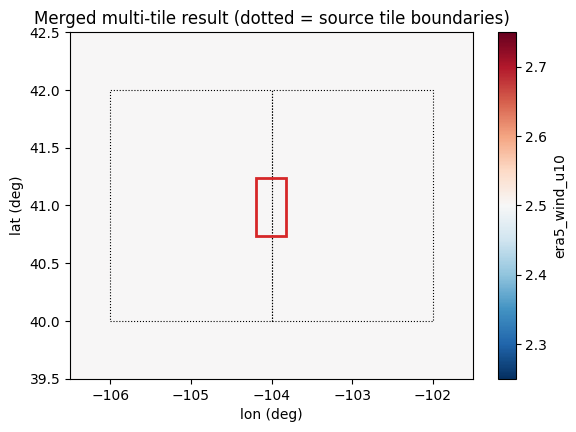

In [6]:
merged = manager.get_data("era5", bbox)
print(
    f"merged tile: data shape={merged.data.shape}  "
    f"lat [{merged.bounds.lat_min}, {merged.bounds.lat_max}]  lon [{merged.bounds.lon_min}, {merged.bounds.lon_max}]"
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.pcolormesh(merged.lons, merged.lats, merged.data[0], shading="auto", cmap="RdBu_r")
for k in keys:
    lat0, lon0 = k.lat_idx * 2 - 90, k.lon_idx * 2 - 180
    ax.add_patch(plt.Rectangle((lon0, lat0), 2, 2, fill=False, ec="k", lw=0.8, ls=":"))
ax.add_patch(
    plt.Rectangle(
        (bbox.lon_min, bbox.lat_min),
        bbox.lon_max - bbox.lon_min,
        bbox.lat_max - bbox.lat_min,
        fill=False,
        ec="tab:red",
        lw=2,
    )
)
ax.set_title("Merged multi-tile result (dotted = source tile boundaries)")
ax.set_xlabel("lon (deg)")
ax.set_ylabel("lat (deg)")
fig.colorbar(im, ax=ax, label="era5_wind_u10")
plt.show()

## 3. Dateline-wrapping boxes are split, not stretched

A footprint near ±180° gets `wraps_dateline=True` from the geometry; the manager
resolves it as two sub-requests (west and east of the dateline) instead of one
absurd 360°-wide box.

In [7]:
dateline_bbox = geometry.compute_footprint_bounding_box(
    boresight_lat_deg=-5.0,
    boresight_lon_deg=179.9,
    subsatellite_lat_deg=-5.0,
    subsatellite_lon_deg=178.9,
    viewing_zenith_deg=45.0,
)
dateline_keys = manager.resolve_tile_keys("era5", dateline_bbox)
lons = sorted({k.lon_idx * 2 - 180 for k in dateline_keys})
print(f"wraps_dateline={dateline_bbox.wraps_dateline}")
print(f"{len(dateline_keys)} tiles, at western edges: {lons}  (both sides of ±180°, nothing in between)")

wraps_dateline=False
1 tiles, at western edges: [178]  (both sides of ±180°, nothing in between)


## 4. Cache behavior: the along-track access pattern

Consecutive footprints along the ground track re-touch most of the same tiles.
Below we sweep a footprint-sized box along a synthetic track and watch hit/miss
stats; then shrink the cache to force LRU eviction.

In [8]:
track = [BoundingBox(lat, lat + 3.0, 10.0 + 0.4 * i, 14.0 + 0.4 * i) for i, lat in enumerate(np.linspace(-20, 20, 60))]
t0 = time.perf_counter()
for box in track:
    manager.get_data("era5", box)
elapsed = time.perf_counter() - t0
stats = manager.get_cache_stats()
print(f"60 along-track requests in {elapsed * 1e3:.1f} ms")
print({k: stats[k] for k in ("hits", "misses", "n_tiles", "current_bytes", "evictions")})

60 along-track requests in 4.7 ms
{'hits': 250, 'misses': 88, 'n_tiles': 88, 'current_bytes': 26400, 'evictions': 0}


The first requests miss and load; after that, the sliding window mostly hits.
The merge cache adds another layer: footprints that resolve to the *identical*
tile set (very common at fine time steps) get the previously merged array back
without re-stitching.

In [9]:
before = manager.get_cache_stats()
for _ in range(50):
    manager.get_data("era5", track[-1])  # same box, same tile set, 50x
after = manager.get_cache_stats()
print(
    f"tile-cache hits {before.get('hits')} -> {after.get('hits')}  "
    f"(merge cache absorbed the repeats: merge_hits {before.get('merge_hits')} -> {after.get('merge_hits')})"
)

tile-cache hits 250 -> 250  (merge cache absorbed the repeats: merge_hits 11 -> 61)


## 5. Prefetch: overlapping I/O with compute

With `prefetch_lookahead > 0` (the default), the orchestrator hands the manager the
bounding boxes of the *next* footprints each iteration; a [background worker](https://docs.python.org/3/library/threading.html) loads
their tiles while the main thread computes PSF weights for the current one —
blocking file I/O releases the [GIL](https://docs.python.org/3/glossary.html#term-global-interpreter-lock), so I/O and compute genuinely overlap. Results
never change — a missed prefetch just means the synchronous path loads the tile.

In [10]:
prefetching = TileManager(
    readers={"era5": ERA5Reader(era5_path)},
    active_mode=OperationalMode.CAM,
    prefetch_lookahead=2,
)
try:
    prefetching.prefetch(track[:3])  # warm the first footprints' tiles in the background
    time.sleep(0.5)  # give the worker a moment (a real run overlaps compute here)
    t0 = time.perf_counter()
    prefetching.get_data("era5", track[0])
    warm_ms = (time.perf_counter() - t0) * 1e3
    stats = prefetching.get_cache_stats()
    print(
        f"get_data after prefetch: {warm_ms:.2f} ms  (hits={stats.get('hits')}, prefetched={stats.get('prefetched')})"
    )
finally:
    prefetching.shutdown()

get_data after prefetch: 0.46 ms  (hits=4, prefetched=9)


## Where this goes next in the stack

The next PR adds **PSF weighting and aggregation**: for each footprint, the
merged grid returned by `get_data` is weighted by the PSF (PR 1) and reduced to
per-variable footprint statistics. The orchestration that drives manager + weights
per granule arrives with `product.py` (PR 7) and the runners (PR 9).